In [1]:
import requests
import pandas as pd

print("Structural Annotation (InterPro / Pfam): ")

# We will use the UniProt ID for BRCA1
uniprot_id = "P38398"

# 1. Query the UniProt API for annotated features (Domains, Binding Sites, Motifs)
url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.json"
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    features = data.get("features", [])
    
    # 2. Filter for structural and functional annotations
    annotation_list = []
    for feature in features:
        f_type = feature.get("type")
        if f_type in ["Domain", "Region", "Binding site", "Motif", "Zinc finger"]:
            description = feature.get("description", "N/A")
            start = feature["location"]["start"]["value"]
            end = feature["location"]["end"]["value"]
            annotation_list.append({
                "Feature Type": f_type,
                "Description": description,
                "Start Residue": start,
                "End Residue": end
            })
            
    # 3. Generate the Functional Annotation Report
    df_annotations = pd.DataFrame(annotation_list)
    print("\n✔️ Functional Annotation Report Generated:")
    display(df_annotations)
    
else:
    print(f"Error fetching data: {response.status_code}")

Structural Annotation (InterPro / Pfam): 

✔️ Functional Annotation Report Generated:


,Feature Type,Description,Start Residue,End Residue
0,Domain,BRCT 1,1642,1736
1,Domain,BRCT 2,1756,1855
2,Zinc finger,RING-type,24,65
3,Region,Disordered,230,270
4,Region,Disordered,306,338
5,Region,Disordered,534,570
6,Region,Disordered,654,709
7,Region,Disordered,1181,1216
8,Region,Disordered,1322,1387
9,Region,Interaction with PALB2,1397,1424


--- Generating Protein Domain Map ---


C:\Users\mitra\AppData\Local\Temp\ipykernel_37424\4084007088.py:30: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((start, 0.3), end - start, 0.4, color=color, edgecolor="black", zorder=2, label=f_type))


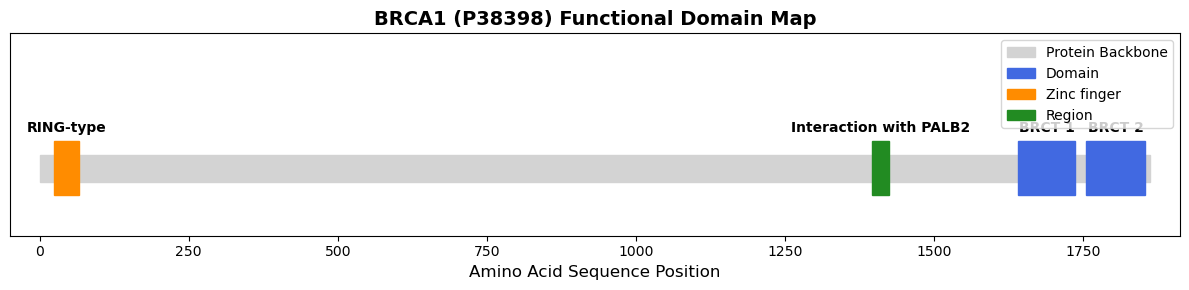

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("--- Generating Protein Domain Map ---")

# Create figure
fig, ax = plt.subplots(figsize=(12, 3))

# Draw the full protein backbone (BRCA1 is 1863 amino acids long)
full_length = 1863
ax.add_patch(patches.Rectangle((0, 0.4), full_length, 0.2, color="lightgray", zorder=1, label="Protein Backbone"))

# Color palette for different features
colors = {"Domain": "royalblue", "Zinc finger": "darkorange", "Region": "forestgreen"}

# Plot each feature
for index, row in df_annotations.iterrows():
    start = int(row["Start Residue"])
    end = int(row["End Residue"])
    f_type = row["Feature Type"]
    desc = row["Description"]
    
    # We will skip plotting the "Disordered" regions to keep the map clean and focus on structured domains
    if "Disordered" in desc:
        continue
        
    color = colors.get(f_type, "red")
    
    # Draw the domain block
    ax.add_patch(patches.Rectangle((start, 0.3), end - start, 0.4, color=color, edgecolor="black", zorder=2, label=f_type))
    
    # Add text label above the block
    ax.text((start + end) / 2, 0.75, desc, ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formatting the plot
ax.set_xlim(-50, full_length + 50)
ax.set_ylim(0, 1.5)
ax.set_yticks([]) # Hide y-axis
ax.set_xlabel("Amino Acid Sequence Position", fontsize=12)
ax.set_title("BRCA1 (P38398) Functional Domain Map", fontsize=14, fontweight='bold')

# Deduplicate legend labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')

plt.tight_layout()
plt.show()